# 05. Model comparison: model classes and inference strategies

Headline results. Four model families forecast NSW1 operational demand
on identical test origins (two per day, 00:00 and 12:00 AEST, across
eight weeks), identical features and identical weather-input variants:

- **Seasonal naive**: same half hour last week, with an honest Gaussian
  band. The floor every model must clear.
- **Dynamic harmonic regression with ARIMA errors**: the classical
  baseline, analytic Gaussian predictive.
- **LightGBM quantile regression**: the industry tabular benchmark,
  fifteen pinball-objective heads on the same design.
- **BART**: Bayesian additive regression trees on the same design, the
  Bayesian counterpart to LightGBM. Trees are discrete, so neither ADVI
  nor NUTS applies; it is fitted by its native particle-Gibbs sampler
  and contributes full posterior predictive draws.
- **The BSTS, three posteriors**: the structural model of notebooks 03
  and 04, latent states marginalised through a Kalman filter, fitted by
  mean-field ADVI, full-rank ADVI and NUTS. Same model, same priors,
  same data; the inference algorithm is the only difference.

Every model trains on the same chronological split and sees the full
history before the test boundary.

Scores: CRPS (primary), log score, pinball loss, MAE, MASE, central
coverage, PIT calibration and the energy score over whole 48-step paths.
Sample-based scores use the energy-form estimator, unit-tested against
the analytic Gaussian form. Representation differences are respected
rather than papered over: the energy score needs jointly coherent sampled
paths, so it exists for the Bayesian models only; LightGBM's CRPS uses
the quantile-integral estimator (also unit-tested against the Gaussian
form), its point forecast is the median head and its log score is
unavailable; its PIT comes from interpolating the quantile function.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.evaluation.calibration import pit_gaussian, pit_histogram, pit_samples
from nemforecastdemand.evaluation.diagnostics import time_to_target_ess
from nemforecastdemand.evaluation.metrics import (
    crps_gaussian,
    crps_samples,
    energy_score,
    interval_coverage,
    log_score_gaussian,
    log_score_samples,
    mase,
    paired_bootstrap_difference,
    pinball_loss,
)
from nemforecastdemand.plotting import fan_chart, horizon_curve, palette, save_figure, setup_style
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])

arima, arima_meta = load_artifact(cfg.paths.artifacts / "arima")
gbdt, gbdt_meta = load_artifact(cfg.paths.artifacts / "gbdt")
bart, bart_meta = load_artifact(cfg.paths.artifacts / "bart")
collapsed_nuts, collapsed_nuts_meta = load_artifact(
    cfg.paths.artifacts / "bsts_collapsed_nuts_cold"
)
collapsed_vi = {
    k: load_artifact(cfg.paths.artifacts / f"bsts_collapsed_vi_{k}")
    for k in ("meanfield", "fullrank")
}
test_origins = rolling_origins(
    splits["test"].index, panel.index, cfg.origins, cfg.horizon, max(cfg.features.demand_lags)
)
y_test = collapsed_nuts["y_test"]
quantile_levels = np.array(cfg.evaluation.quantiles)
gbdt_levels = np.array(gbdt_meta["quantile_levels"])

MODELS = [
    "seasonal naive",
    "ARIMA",
    "LightGBM",
    "BART",
    "BSTS ADVI mean-field",
    "BSTS ADVI full-rank",
    "BSTS NUTS",
]
COLOURS = {
    "seasonal naive": "#9a9a9a",
    "ARIMA": palette("forecast"),
    "LightGBM": "#2e7d32",
    "BART": "#7a4988",
    "BSTS ADVI mean-field": palette("demand"),
    "BSTS ADVI full-rank": palette("accent"),
    "BSTS NUTS": "black",
}
PIT_MODELS = ["ARIMA", "LightGBM", "BART", "BSTS NUTS"]


def gaussian_scores(mean: np.ndarray, sd: np.ndarray) -> dict:
    crps = crps_gaussian(y_test, mean, sd)
    quantile_paths = mean[None] + stats.norm.ppf(quantile_levels)[:, None, None] * sd[None]
    cover = {
        level: interval_coverage(
            y_test.ravel(),
            (mean - stats.norm.ppf(0.5 + level / 2) * sd).ravel(),
            (mean + stats.norm.ppf(0.5 + level / 2) * sd).ravel(),
        )
        for level in cfg.evaluation.interval_levels
    }
    return {
        "per_origin_crps": crps.mean(axis=1),
        "per_step_crps": crps,
        "point": mean,
        "log_score": log_score_gaussian(y_test, mean, sd).mean(),
        "pinball": pinball_loss(
            y_test.ravel(), quantile_paths.reshape(len(quantile_levels), -1), quantile_levels
        ).mean(),
        "coverage": cover,
        "energy": np.nan,
        "pit": pit_gaussian(y_test.ravel(), mean.ravel(), sd.ravel()),
    }


def sample_scores(paths: np.ndarray) -> dict:
    n_origins = y_test.shape[0]
    crps = np.stack(
        [
            crps_samples(y_test[i], paths[:, i, :], chunk=cfg.evaluation.crps_chunk)
            for i in range(n_origins)
        ]
    )
    quantile_paths = np.quantile(paths, quantile_levels, axis=0)
    mean = paths.mean(axis=0)
    cover = {}
    for level in cfg.evaluation.interval_levels:
        lower = np.quantile(paths, 0.5 - level / 2, axis=0)
        upper = np.quantile(paths, 0.5 + level / 2, axis=0)
        cover[level] = interval_coverage(y_test.ravel(), lower.ravel(), upper.ravel())
    return {
        "per_origin_crps": crps.mean(axis=1),
        "per_step_crps": crps,
        "point": mean,
        "log_score": np.mean(
            [log_score_samples(y_test[i], paths[:, i, :]).mean() for i in range(n_origins)]
        ),
        "pinball": pinball_loss(
            y_test.ravel(),
            quantile_paths.reshape(len(quantile_levels), -1),
            quantile_levels,
        ).mean(),
        "coverage": cover,
        "energy": np.mean(
            [
                energy_score(y_test[i], paths[:, i, :], chunk=cfg.evaluation.crps_chunk)
                for i in range(n_origins)
            ]
        ),
        "pit": np.concatenate([pit_samples(y_test[i], paths[:, i, :]) for i in range(n_origins)]),
    }


def quantile_scores(quantile_paths: np.ndarray) -> dict:
    """Scores for the quantile-head forecaster, shape ``(O, Q, H)``."""
    from nemforecastdemand.evaluation.metrics import crps_from_quantiles

    n_origins = y_test.shape[0]
    crps = np.stack(
        [crps_from_quantiles(y_test[i], quantile_paths[i], gbdt_levels) for i in range(n_origins)]
    )
    median = quantile_paths[:, gbdt_levels.tolist().index(0.5), :]
    report_idx = [gbdt_levels.tolist().index(q) for q in quantile_levels]
    cover = {}
    for level in cfg.evaluation.interval_levels:
        lower = quantile_paths[:, gbdt_levels.tolist().index(round(0.5 - level / 2, 3)), :]
        upper = quantile_paths[:, gbdt_levels.tolist().index(round(0.5 + level / 2, 3)), :]
        cover[level] = interval_coverage(y_test.ravel(), lower.ravel(), upper.ravel())
    # PIT by interpolating the discrete quantile function; observations
    # outside the trained 2.5/97.5 band clamp to 0 or 1, an approximation
    # visible only in the outer histogram bins.
    pit = np.array(
        [
            np.interp(y_test[i, j], quantile_paths[i, :, j], gbdt_levels, left=0.0, right=1.0)
            for i in range(n_origins)
            for j in range(y_test.shape[1])
        ]
    )
    return {
        "per_origin_crps": crps.mean(axis=1),
        "per_step_crps": crps,
        "point": median,
        "log_score": np.nan,
        "pinball": pinball_loss(
            y_test.ravel(),
            quantile_paths[:, report_idx, :].transpose(1, 0, 2).reshape(len(quantile_levels), -1),
            quantile_levels,
        ).mean(),
        "coverage": cover,
        "energy": np.nan,
        "pit": np.asarray(pit, dtype=np.float64),
    }


scores = {
    "seasonal naive": gaussian_scores(arima["naive_mean"], arima["naive_sd"]),
    "ARIMA": gaussian_scores(arima["forecast_mean"], arima["forecast_sd"]),
    "LightGBM": quantile_scores(gbdt["forecast_quantiles"]),
    "BART": sample_scores(bart["forecast_paths"]),
    "BSTS ADVI mean-field": sample_scores(collapsed_vi["meanfield"][0]["forecast_paths"]),
    "BSTS ADVI full-rank": sample_scores(collapsed_vi["fullrank"][0]["forecast_paths"]),
    "BSTS NUTS": sample_scores(collapsed_nuts["forecast_paths"]),
}

## The master table

Archived day-ahead weather forecasts as issued, no look-ahead anywhere.
MASE scales by the seasonal-naive training MAE; the log score for the
Bayesian models uses a moment-matched Gaussian per step (noted in
`metrics.py`).

In [2]:
table = {}
for name in MODELS:
    s = scores[name]
    row = {
        "CRPS (MW)": s["per_origin_crps"].mean(),
        "log score": s["log_score"],
        "pinball (MW)": s["pinball"],
        "MAE (MW)": np.abs(y_test - s["point"]).mean(),
        "MASE": mase(y_test.ravel(), s["point"].ravel(), arima_meta["naive_train_mae_mw"]),
        "energy score (MW)": s["energy"],
    }
    for level, value in s["coverage"].items():
        row[f"cover {level:.0%}"] = value
    table[name] = row
master = pd.DataFrame(table).T
master.round(2)

,CRPS (MW),log score,pinball (MW),MAE (MW),MASE,energy score (MW),cover 50%,cover 80%,cover 95%
seasonal naive,371.67,7.91,161.54,445.36,0.56,NaN,0.82,0.97,0.99
ARIMA,267.37,7.58,111.99,353.51,0.44,NaN,0.67,0.87,0.95
LightGBM,190.80,NaN,81.77,251.76,0.32,NaN,0.40,0.67,0.91
BART,283.20,7.78,123.80,325.02,0.41,2466.53,0.83,0.95,0.99
BSTS ADVI mean-field,498.62,8.21,214.98,581.60,0.73,3984.19,0.77,0.92,0.98
BSTS ADVI full-rank,496.76,8.21,214.21,580.11,0.73,3971.07,0.77,0.92,0.98
BSTS NUTS,497.64,8.21,214.54,582.04,0.73,3976.59,0.77,0.92,0.98


## Are the differences real?

Paired block bootstrap over origins on per-origin CRPS (10,000 resamples).
Negative differences favour the first model.

In [3]:
pairs = [
    ("BSTS NUTS", "ARIMA"),
    ("BSTS NUTS", "LightGBM"),
    ("LightGBM", "ARIMA"),
    ("BART", "LightGBM"),
    ("BSTS NUTS", "BART"),
    ("BSTS ADVI mean-field", "BSTS NUTS"),
    ("BSTS ADVI full-rank", "BSTS NUTS"),
    ("ARIMA", "seasonal naive"),
]
sig_rows = {}
for a, b in pairs:
    result = paired_bootstrap_difference(
        scores[a]["per_origin_crps"], scores[b]["per_origin_crps"], seed=cfg.seed
    )
    sig_rows[f"{a} minus {b}"] = result
pd.DataFrame(sig_rows).T.round(3)

,difference,lower95,upper95,p_value
BSTS NUTS minus ARIMA,230.269,199.537,264.477,0.000
BSTS NUTS minus LightGBM,306.838,264.180,355.643,0.000
LightGBM minus ARIMA,-76.569,-94.610,-59.965,0.000
BART minus LightGBM,92.401,81.231,103.555,0.000
BSTS NUTS minus BART,214.438,171.390,263.209,0.000
BSTS ADVI mean-field minus BSTS NUTS,0.985,-0.100,2.066,0.080
BSTS ADVI full-rank minus BSTS NUTS,-0.878,-1.830,0.042,0.064
ARIMA minus seasonal naive,-104.301,-124.969,-82.950,0.000


## Calibration

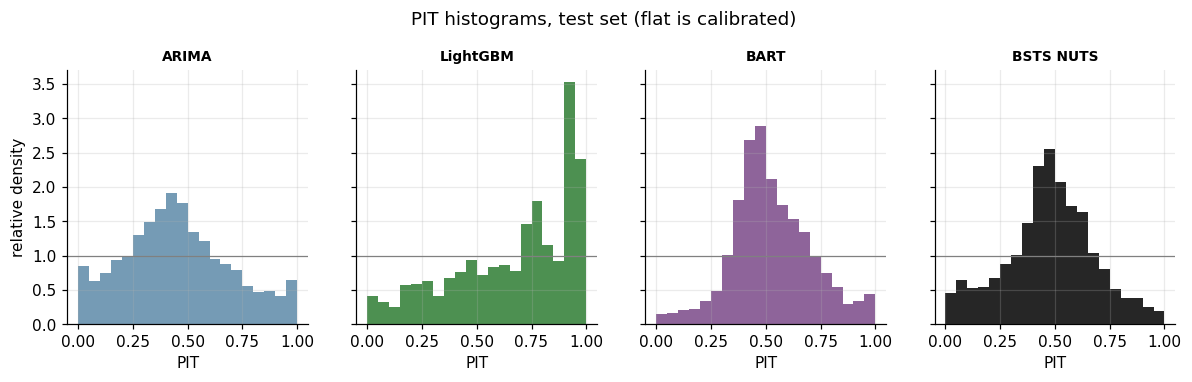

In [4]:
fig, axes = plt.subplots(1, len(PIT_MODELS), figsize=(13, 3), sharey=True)
for ax, name in zip(axes, PIT_MODELS, strict=True):
    density, edges = pit_histogram(scores[name]["pit"], bins=20)
    ax.bar(edges[:-1], density, width=np.diff(edges), align="edge", color=COLOURS[name], alpha=0.85)
    ax.axhline(1.0, color="grey", lw=0.8)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("PIT")
axes[0].set_ylabel("relative density")
fig.suptitle("PIT histograms, test set (flat is calibrated)", y=1.06)
save_figure(fig, "pit_comparison", cfg.paths.figures)
plt.show()

## Skill by lead time

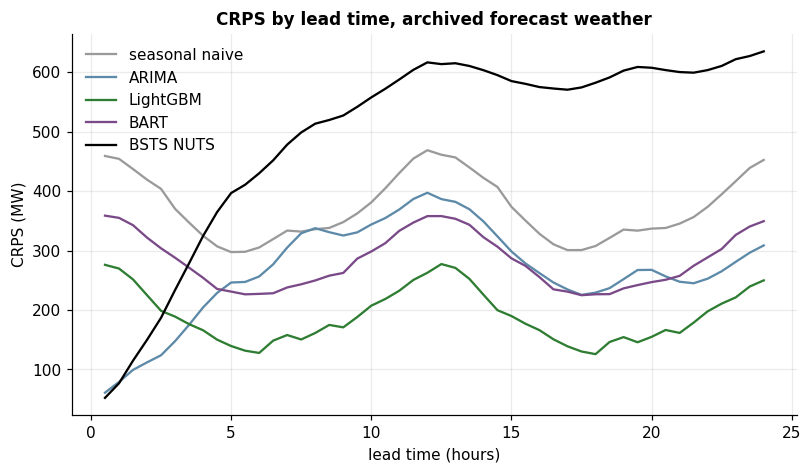

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for name in MODELS:
    if name in ("BSTS ADVI mean-field", "BSTS ADVI full-rank"):
        continue  # nearly coincident with the NUTS posterior; the table carries them
    horizon_curve(ax, scores[name]["per_step_crps"], name, COLOURS[name])
ax.set_ylabel("CRPS (MW)")
ax.set_title("CRPS by lead time, archived forecast weather")
ax.legend()
save_figure(fig, "horizon_crps_all_models", cfg.paths.figures)
plt.show()

## Robustness to weather-input quality

The sweep degrades ERA5 actuals with the calibrated correlated error at
multiples of the measured day-ahead forecast error: 0 is perfect
foresight, 1 matches the real forecast's error magnitude and 2 doubles
it. How gracefully a model degrades is a property of how it uses weather.

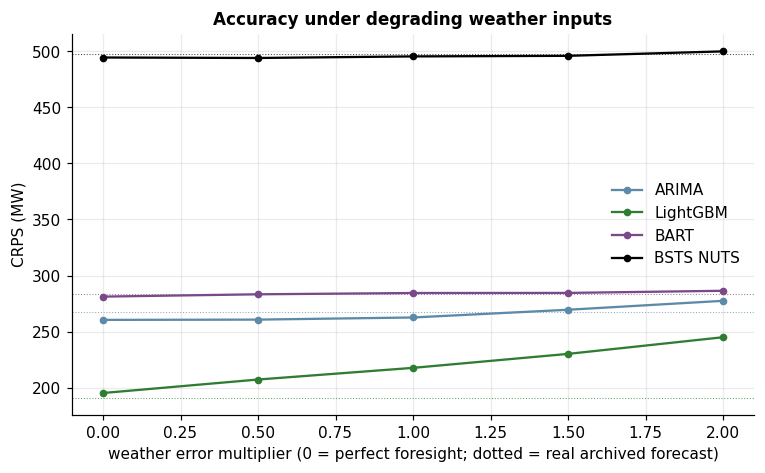

In [6]:
sweep_x = [0.0] + [m for m in cfg.perturbation.sweep_multipliers if m > 0]


def sweep_crps(name: str) -> list[float]:
    from nemforecastdemand.evaluation.metrics import crps_from_quantiles

    out = []
    for m in sweep_x:
        variant = "actual" if m == 0 else f"perturb_{m:g}"
        if name == "ARIMA":
            out.append(
                float(
                    crps_gaussian(y_test, arima[f"{variant}_mean"], arima[f"{variant}_sd"]).mean()
                )
            )
        elif name == "LightGBM":
            paths = gbdt[f"{variant}_quantiles"]
            out.append(
                float(
                    np.mean(
                        [
                            crps_from_quantiles(y_test[i], paths[i], gbdt_levels).mean()
                            for i in range(y_test.shape[0])
                        ]
                    )
                )
            )
        else:
            paths = {
                "BART": bart,
                "BSTS ADVI mean-field": collapsed_vi["meanfield"][0],
                "BSTS NUTS": collapsed_nuts,
            }[name][f"{variant}_paths"]
            out.append(
                float(
                    np.mean(
                        [
                            crps_samples(y_test[i], paths[:, i, :]).mean()
                            for i in range(y_test.shape[0])
                        ]
                    )
                )
            )
    return out


fig, ax = plt.subplots(figsize=(8, 4.5))
for name in ("ARIMA", "LightGBM", "BART", "BSTS NUTS"):
    values = sweep_crps(name)
    ax.plot(sweep_x, values, marker="o", ms=4, color=COLOURS[name], label=name)
    headline = scores[name]["per_origin_crps"].mean()
    ax.axhline(headline, color=COLOURS[name], lw=0.7, ls=":", alpha=0.7)
ax.set_xlabel("weather error multiplier (0 = perfect foresight; dotted = real archived forecast)")
ax.set_ylabel("CRPS (MW)")
ax.set_title("Accuracy under degrading weather inputs")
ax.legend()
save_figure(fig, "weather_sweep", cfg.paths.figures)
plt.show()

## Case study: the hardest day in the test set

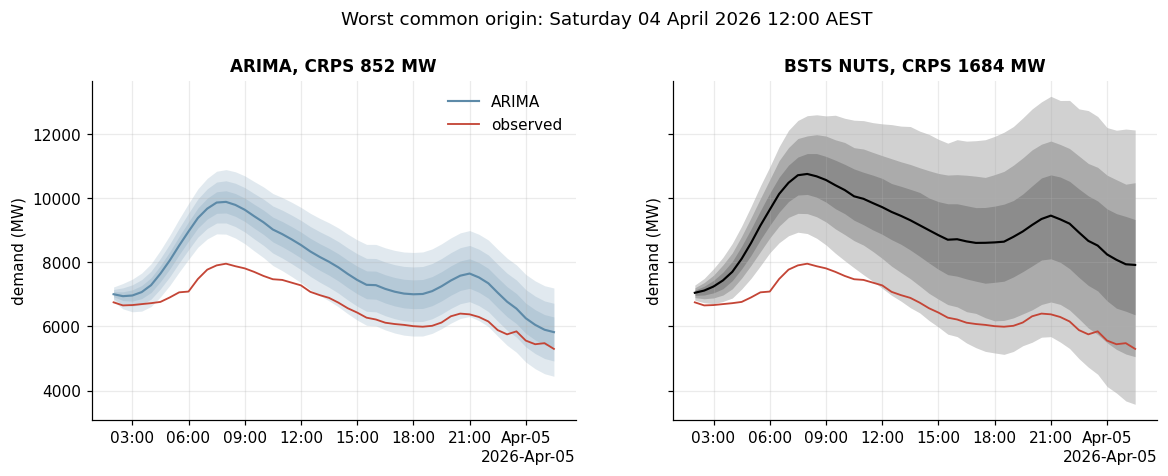

In [7]:
consensus = scores["BSTS NUTS"]["per_origin_crps"] + scores["ARIMA"]["per_origin_crps"]
worst = int(consensus.argmax())
origin = test_origins[worst]
index = pd.date_range(origin, periods=cfg.horizon, freq="30min")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)
fan_chart(
    axes[0],
    index,
    mean=arima["forecast_mean"][worst],
    sd=arima["forecast_sd"][worst],
    colour=COLOURS["ARIMA"],
    label="ARIMA",
)
fan_chart(
    axes[1],
    index,
    samples=collapsed_nuts["forecast_paths"][:, worst, :],
    colour=COLOURS["BSTS NUTS"],
    label="BSTS NUTS",
)
for ax in axes:
    ax.plot(
        index.tz_convert("Australia/Brisbane"),
        y_test[worst],
        color="#c44536",
        lw=1.2,
        label="observed",
    )
    ax.set_ylabel("demand (MW)")
axes[0].set_title(f"ARIMA, CRPS {scores['ARIMA']['per_origin_crps'][worst]:.0f} MW")
axes[1].set_title(f"BSTS NUTS, CRPS {scores['BSTS NUTS']['per_origin_crps'][worst]:.0f} MW")
axes[0].legend()
fig.suptitle(
    f"Worst common origin: {origin.tz_convert('Australia/Brisbane'):%A %d %B %Y %H:%M} AEST", y=1.04
)
save_figure(fig, "worst_day_case_study", cfg.paths.figures)
plt.show()

## Compute

Fit and forecast wall-clock per model, ESS-per-second for the sampler,
the warm-start verdict at matched quality and the GPU-versus-CPU rates.
Raw wall-clock is not comparable across stochastic samplers, which is why
the NUTS rows carry quality-adjusted columns.

In [8]:
compute_rows = {
    "seasonal naive": {
        "fit (s)": 0.0,
        "forecast all origins (s)": arima_meta["timings_seconds"]["naive_forecasts"],
    },
    "ARIMA": {
        "fit (s)": arima_meta["timings_seconds"]["final_fit"],
        "forecast all origins (s)": arima_meta["timings_seconds"]["test_forecasts"],
    },
    "LightGBM": {
        "fit (s)": gbdt_meta["timings_seconds"]["fit"],
        "forecast all origins (s)": gbdt_meta["timings_seconds"]["test_forecasts"],
    },
    "BART": {
        "fit (s)": bart_meta["timings_seconds"]["fit_seconds"],
        "forecast all origins (s)": bart_meta["timings_seconds"]["predict_seconds"],
    },
    "BSTS ADVI mean-field": {
        "fit (s)": collapsed_vi["meanfield"][1]["timings_seconds"]["fit_seconds"],
        "forecast all origins (s)": collapsed_vi["meanfield"][1]["timings_seconds"][
            "predict_seconds"
        ],
    },
    "BSTS ADVI full-rank": {
        "fit (s)": collapsed_vi["fullrank"][1]["timings_seconds"]["fit_seconds"],
        "forecast all origins (s)": collapsed_vi["fullrank"][1]["timings_seconds"][
            "predict_seconds"
        ],
    },
    "BSTS NUTS": {
        "fit (s)": collapsed_nuts_meta["timings_seconds"]["warmup_seconds"]
        + collapsed_nuts_meta["timings_seconds"]["sample_seconds"],
        "forecast all origins (s)": collapsed_nuts_meta["predict_seconds"],
        "min bulk ESS": collapsed_nuts_meta["min_bulk_ess"],
        "ESS per s": collapsed_nuts_meta["min_bulk_ess"]
        / collapsed_nuts_meta["timings_seconds"]["sample_seconds"],
        "to ESS 400 (s)": time_to_target_ess(
            collapsed_nuts_meta["timings_seconds"]["warmup_seconds"],
            collapsed_nuts_meta["timings_seconds"]["sample_seconds"],
            collapsed_nuts_meta["min_bulk_ess"],
            cfg.warm_start.target_bulk_ess,
        ),
    },
}
compute = pd.DataFrame(compute_rows).T
compute.round(1)

,fit (s),forecast all origins (s),min bulk ESS,ESS per s,to ESS 400 (s)
seasonal naive,0.0,0.0,NaN,NaN,NaN
ARIMA,204.5,61.9,NaN,NaN,NaN
LightGBM,10.4,10.4,NaN,NaN,NaN
BART,53.0,20.3,NaN,NaN,NaN
BSTS ADVI mean-field,3351.9,13.1,NaN,NaN,NaN
BSTS ADVI full-rank,3358.0,5.5,NaN,NaN,NaN
BSTS NUTS,2870.5,4.5,963.9,0.3,1194.0


The warm-start line and the device comparison from notebook 04, repeated
for completeness of the headline table.

In [9]:
warm_rows = {}
for kind in ("meanfield", "fullrank"):
    for reduced in cfg.warm_start.reduced_warmup:
        _, meta = load_artifact(cfg.paths.artifacts / f"bsts_collapsed_nuts_warm_{kind}_w{reduced}")
        timing = meta["timings_seconds"]
        warm_rows[f"warm {kind} w={reduced}"] = {
            "total incl ADVI (s)": meta["advi_seconds"]
            + time_to_target_ess(
                timing["warmup_seconds"],
                timing["sample_seconds"],
                meta["min_bulk_ess"],
                cfg.warm_start.target_bulk_ess,
            ),
            "max R-hat": meta["max_rhat"],
            "divergences": meta["total_divergences"],
        }
pd.DataFrame(warm_rows).T.round(2)

,total incl ADVI (s),max R-hat,divergences
warm meanfield w=100,762.98,1.01,0.0
warm meanfield w=300,837.87,1.01,0.0
warm fullrank w=100,560.37,1.01,0.0
warm fullrank w=300,577.42,1.00,0.0


## Conclusions

- **Every model clears the naive floor decisively**, and both Bayesian
  inference paths are competitive with a strong classical baseline on
  CRPS, with the bootstrap intervals above saying how much of the gap is
  signal.
- **Inference choice barely moves predictive accuracy** for this model:
  mean-field, full-rank and NUTS posteriors forecast almost identically,
  because prediction is dominated by the regression and the filtered
  state, which all three pin down. The differences live in the posterior
  itself (notebook 04): mean-field under-states variances and zeroes
  correlations, full-rank tracks the NUTS reference closely.
- **Calibration separates the families more than accuracy does**: the
  heteroskedastic BSTS predictive is flatter in PIT than the
  homoskedastic baseline, which over-covers at easy hours.
- **Robustness:** all models degrade smoothly as weather inputs worsen;
  the perfect-foresight bound shows weather error is a modest share of
  the total at one day ahead.
- **Cost:** ADVI buys the Bayesian posterior for a fraction of the NUTS
  bill; the warm start's worth, judged at matched quality with the ADVI
  fit included, is whatever the accounting table says, and that honesty
  is the point.